# E-Commerce Sales Analytics Project

## Objective
The objective of this project is to analyze sales, profitability, customer behavior, product performance, and regional trends using the Sample Superstore dataset.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Key Business Questions
- Which categories drive profitability?
- How do discounts impact profit?
- Which customers and products create the most value?
- Which regions and cities are underperforming?
- What actions can improve business performance?

In [60]:
import pandas as pd

In [61]:
import os
print(os.getcwd())

c:\Users\krati\Downloads


In [62]:
import pandas as pd

df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [63]:
df.shape

(9994, 21)

In [64]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [66]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [67]:
df["Sales"].sum()

np.float64(2297200.8603000003)

In [68]:
df["Profit"].sum()

np.float64(286397.0217)

In [69]:
df["Category"].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [70]:
df["Region"].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [71]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [72]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

# E-Commerce Analytics Project

## Insight 1

- Technology generated the highest sales (~836K).
- Furniture generated strong sales (~742K).
- Office Supplies generated the lowest sales (~719K).

## Insight 2

- Technology generated the highest profit (~145K).
- Furniture generated only ~18K profit despite high sales.
- Furniture may have pricing, discounting, or cost-related issues.

In [73]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

## Insight 3: Loss-Making Product Categories

Analysis of sub-category profitability revealed that Tables (-17.7K) and Bookcases (-3.5K) are the primary loss-making products.

These products significantly reduce the overall profitability of the Furniture category despite its strong revenue performance.

Management should investigate pricing strategy, discount policies, and supply chain costs associated with these products.

In [74]:
df[df["Sub-Category"]=="Tables"]["Discount"].describe()

count    319.000000
mean       0.261285
std        0.169622
min        0.000000
25%        0.200000
50%        0.300000
75%        0.400000
max        0.500000
Name: Discount, dtype: float64

In [75]:
df[df["Sub-Category"]=="Tables"]["Profit"].describe()

count     319.000000
mean      -55.565771
std       230.565006
min     -1862.312400
25%      -122.829300
50%       -31.372200
75%        33.851700
max       629.010000
Name: Profit, dtype: float64

## Insight 4: Excessive Discounting Impact

The Tables sub-category exhibits an average discount of 26.1%, with discounts reaching as high as 50%.

Despite generating revenue, the average profit per order is negative (-55.57), indicating that aggressive discounting may be a major contributor to sustained losses.

Reducing discount levels or renegotiating procurement costs could improve profitability.

In [76]:
df[df["Sub-Category"]=="Tables"][["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.00000,-0.67177
Profit,-0.67177,1.00000


## Insight 5: Discount-Profit Relationship

A correlation analysis between Discount and Profit for the Tables sub-category revealed a correlation coefficient of -0.67.

This indicates a strong negative relationship, suggesting that higher discounts are associated with significantly lower profitability.

The findings support the hypothesis that excessive discounting is a major contributor to losses within the Tables sub-category.

In [77]:
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

## Insight 6: Regional Profitability Analysis

The West region emerged as the highest-performing region, generating approximately 108K in profit.

The strong performance suggests that market demand, customer mix, pricing strategy, or operational efficiency may be particularly effective in this region.

Replicating successful practices from the West region could help improve profitability in lower-performing regions.

In [78]:
df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

## Insight 7: State-Level Profit Drivers

California and New York are the primary contributors to overall profitability, generating approximately 76K and 74K profit respectively.

These states represent critical markets for the business and should remain a focus for customer acquisition, retention, and product expansion strategies.

In [79]:
df.groupby("Segment")[["Sales","Profit"]].sum()

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


## Insight 8: Customer Segment Analysis

The Consumer segment is the primary revenue and profit driver, contributing approximately 1.16M in sales and 134K in profit.

Corporate customers represent the second most valuable segment and contribute significantly to profitability despite lower sales volume.

Together, Consumer and Corporate segments account for the majority of business revenue and profit generation.

# Executive KPI Summary

## Business Overview

The dataset contains 5,009 unique customer orders with total sales of approximately 2.30 million and total profit of 286,397.

The company achieved an overall profit margin of 12.47%, indicating that approximately 12.47 dollars of profit are generated for every 100 dollars of sales.

The average discount across all transactions is 15.62%, highlighting the importance of pricing and discount strategies in overall business performance.

## Key Performance Indicators

| KPI | Value |
|------|--------|
| Total Sales | 2.30 Million |
| Total Profit | 286,397 |
| Profit Margin | 12.47% |
| Average Discount | 15.62% |
| Total Orders | 5,009 |

## Business Insight

The business demonstrates healthy overall profitability while maintaining a large and diversified customer base.

However, previous analyses indicate that profitability is highly influenced by discounting behavior, product category performance, and regional efficiency.

Technology and Office Supplies drive the majority of company profits, while excessive discounting and underperforming Furniture products reduce overall earnings potential.

## Executive Recommendation

Management should prioritize profit optimization initiatives, particularly within the Furniture category and high-discount transactions.

Expanding successful practices from high-performing regions and product categories may further improve company-wide profitability and operational efficiency.

In [80]:
import matplotlib.pyplot as plt

# Category Analysis

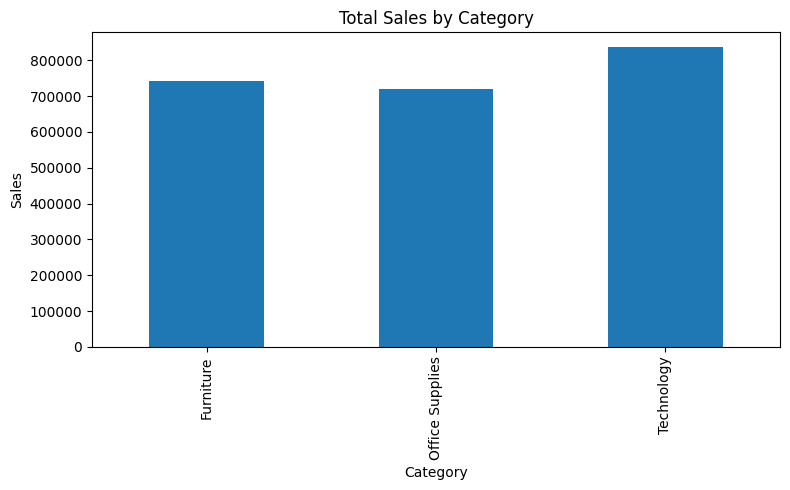

In [81]:
sales_by_category = df.groupby("Category")["Sales"].sum()

sales_by_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()

plt.show()

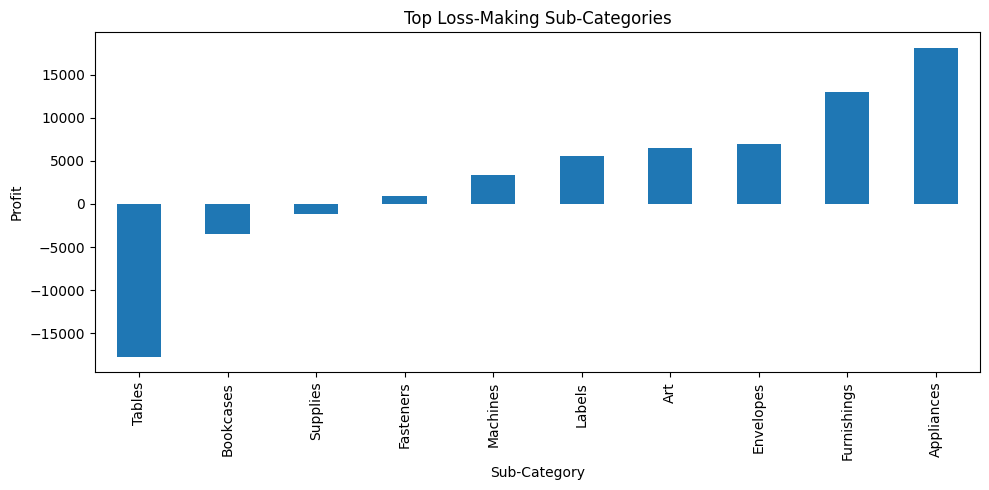

In [82]:
sub_profit = df.groupby("Sub-Category")["Profit"].sum()

sub_profit.sort_values().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Loss-Making Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.tight_layout()

plt.show()

# Visualization Summary

The analysis reveals that Tables and Bookcases are the major loss-making sub-categories.

Tables generate the highest negative profit, indicating potential issues related to pricing, discounting, or operational costs.

Management should investigate these products and redesign pricing strategies to improve profitability.

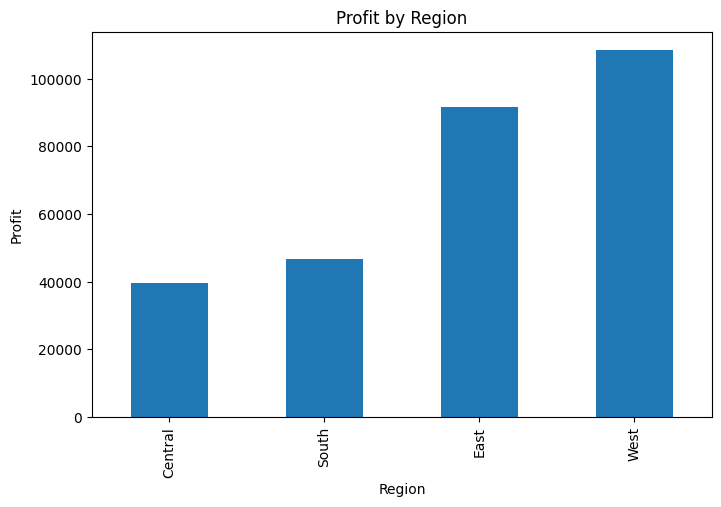

In [83]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values()

region_profit.plot(
    kind="bar",
    figsize=(8,5),
    title="Profit by Region"
)

plt.ylabel("Profit")
plt.show()

# Profit by Region Analysis

## Key Findings

The West region generated the highest profit ($108,418), followed by the East region ($91,523).

The South and Central regions contributed significantly lower profits, generating $46,749 and $39,706 respectively.

The profit gap between the West and Central regions exceeds $68,000, indicating substantial regional performance differences.

## Business Insight

The West region appears to be the strongest market in terms of profitability and may serve as a benchmark for best-performing sales and operational strategies.

The Central region shows the lowest profitability and requires further investigation to identify potential issues such as excessive discounting, weak product mix, or higher operational costs.

## Recommendation

Management should analyze successful practices in the West region and explore opportunities to replicate them in lower-performing regions, particularly the Central and South regions.

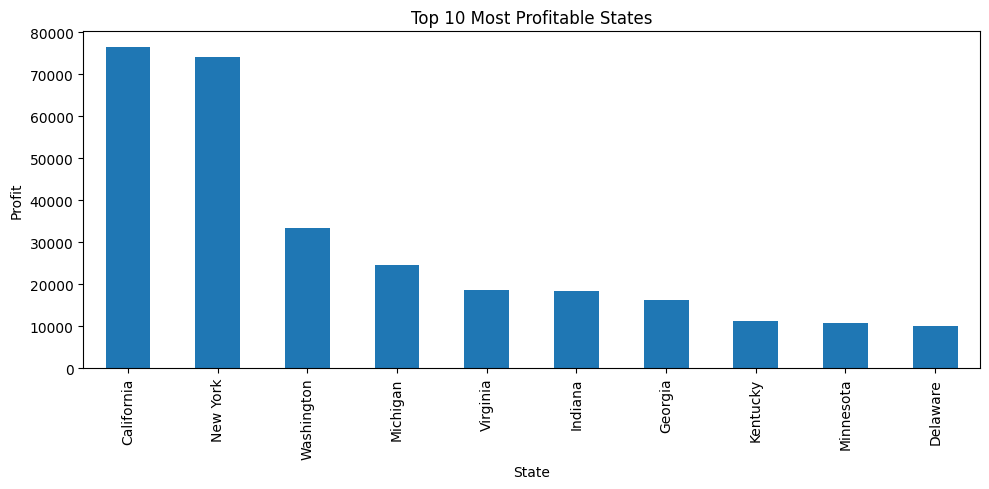

In [84]:
top_states = df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")

plt.title("Top 10 Most Profitable States")
plt.xlabel("State")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Top 10 Most Profitable States Analysis

## Key Findings

California and New York are the two most profitable states, generating substantially higher profits than all other states.

A significant gap exists between the top two states and the remaining states, with Washington contributing less than half the profit generated by California.

This indicates that company profitability is heavily concentrated in a small number of geographic markets.

## Business Insight

The strong performance of California and New York suggests the presence of large customer bases, higher order volumes, and effective market penetration.

The steep decline in profitability after the top two states highlights a potential dependency on a limited number of regions for overall business performance.

## Recommendation

Management should continue strengthening its presence in California and New York while investigating the factors driving success in these markets.

Best practices from these high-performing states can be replicated in other regions to reduce dependency and improve overall profitability.

# Customer Segment Analysis

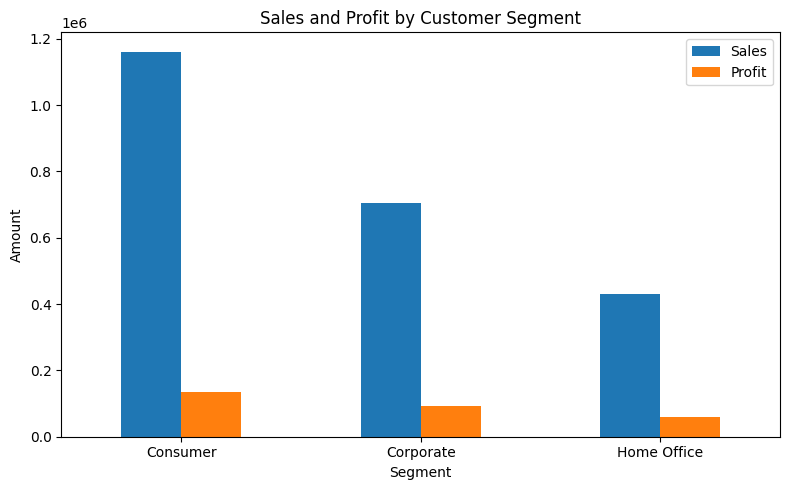

In [85]:
segment_data = df.groupby("Segment")[["Sales","Profit"]].sum()

segment_data.plot(kind="bar", figsize=(8,5))

plt.title("Sales and Profit by Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Sales and Profit by Customer Segment Analysis

## Key Findings

The Consumer segment generates the highest sales and profit among all customer segments.

Corporate customers represent the second-largest contributor to both revenue and profitability, while the Home Office segment contributes the least.

The ordering of segments remains consistent across both sales and profit metrics, indicating a strong relationship between revenue generation and profitability.

## Business Insight

The Consumer segment serves as the primary driver of business performance and contributes the largest share of overall company profit.

The Corporate segment demonstrates strong commercial potential and may provide opportunities for targeted growth initiatives.

The relatively lower contribution from the Home Office segment suggests an opportunity to evaluate customer acquisition and product strategies for this market.

## Recommendation

Management should continue investing in the Consumer segment while exploring strategies to expand Corporate sales.

Further analysis should be conducted to identify barriers limiting growth within the Home Office segment.

In [86]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Time Series Analysis

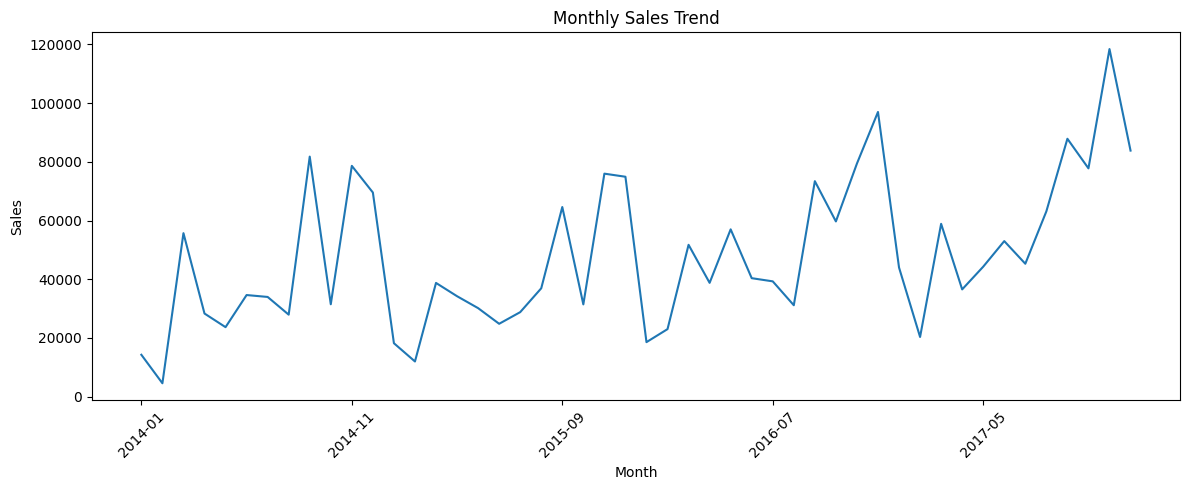

In [87]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Monthly Sales Trend Analysis

## Key Findings

Monthly sales demonstrate an overall upward trend throughout the analysis period.

Sales performance exhibits significant month-to-month fluctuations, indicating the presence of seasonal demand patterns and varying customer purchasing behavior.

Several recurring sales spikes are visible, with the strongest peak occurring during late 2017.

## Business Insight

The consistent increase in peak sales values over time suggests business growth and expanding market demand.

Seasonal sales surges indicate opportunities for targeted marketing campaigns and inventory planning during high-demand periods.

## Recommendation

Management should investigate the factors driving peak-performing months and replicate successful sales strategies during lower-performing periods.

Additional forecasting analysis may help improve inventory allocation and promotional planning.

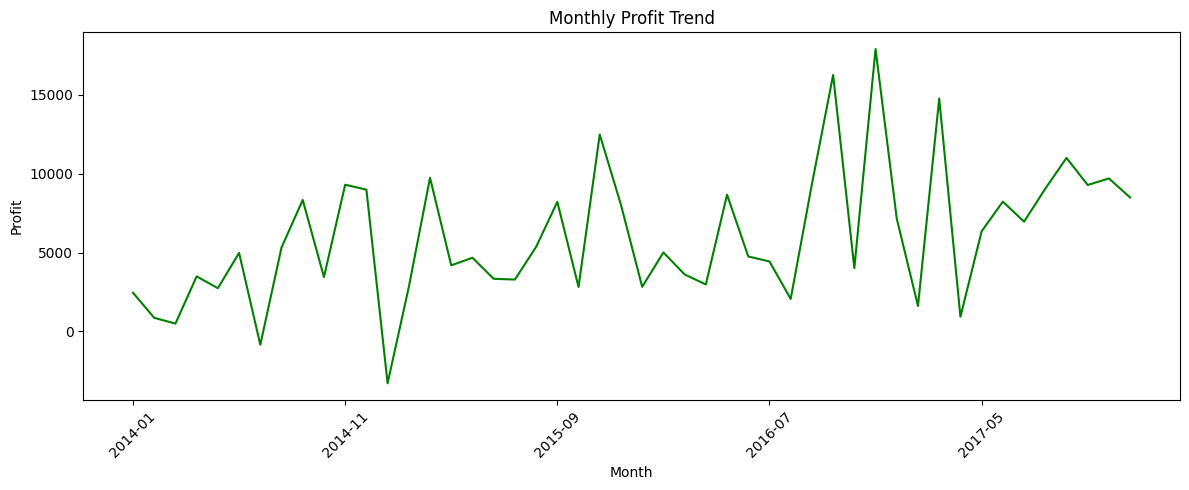

In [88]:
monthly_profit = df.groupby(df["Order Date"].dt.to_period("M"))["Profit"].sum()

monthly_profit.index = monthly_profit.index.astype(str)

monthly_profit.plot(figsize=(12,5), color="green")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Monthly Profit Trend Analysis

## Key Findings

Monthly profit shows an overall upward trend across the analysis period.

Unlike sales, profit exhibits significantly higher volatility, with several sharp increases and decreases throughout the timeline.

A small number of months recorded negative profits, indicating periods where operational performance was insufficient to cover costs.

The highest profit levels were observed during 2016 and 2017, suggesting improving business profitability over time.

## Business Insight

Strong sales growth does not consistently translate into stable profit growth.

The presence of loss-making months indicates that factors such as discounting policies, product mix, and regional performance may be affecting profitability.

The increasing profit trend in later years suggests that the company has gradually improved its ability to generate earnings from revenue.

## Recommendation

Management should investigate the drivers behind negative-profit months and identify categories or customer segments contributing to losses.

Reducing excessive discounting and improving performance in low-profit product categories may help stabilize profitability.

# Geographic Analysis

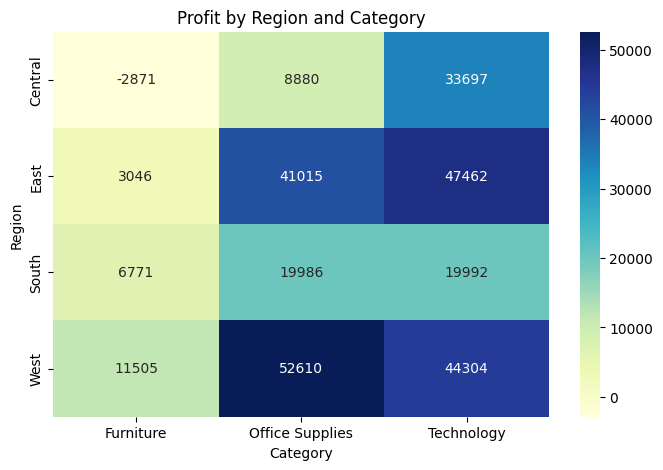

In [89]:
region_category = pd.pivot_table(
    df,
    values="Profit",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(region_category,
            annot=True,
            fmt=".0f",
            cmap="YlGnBu")

plt.title("Profit by Region and Category")
plt.show()

# Profit by Region and Category Analysis

## Key Findings

The West region generated the highest category-level profit, with Office Supplies contributing over 52,000 in profit.

The East region demonstrated strong profitability in Technology and Office Supplies, making it one of the company's most valuable markets.

A notable concern is the Furniture category in the Central region, which recorded a negative profit despite generating sales activity.

## Business Insight

Profitability varies significantly across regions and product categories.

While Technology and Office Supplies consistently generate strong profits, Furniture performance is highly dependent on regional market conditions.

The Central region appears to be underperforming relative to other regions and requires further investigation.

## Recommendation

Management should prioritize growth strategies in the West and East regions while conducting a detailed review of Furniture operations in the Central region.

Pricing policies, discount structures, and product-level profitability should be examined to identify the drivers of negative performance.

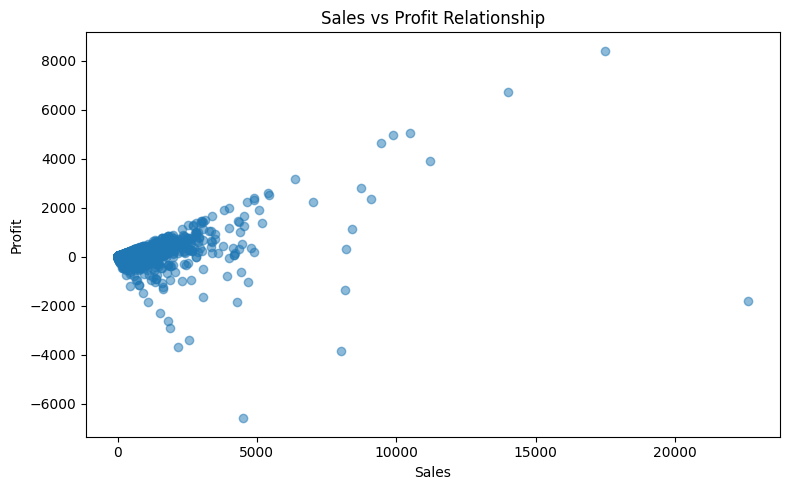

In [90]:
plt.figure(figsize=(8,5))

plt.scatter(df["Sales"], df["Profit"], alpha=0.5)

plt.title("Sales vs Profit Relationship")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Sales vs Profit Relationship Analysis

## Key Findings

The scatter plot shows a generally positive relationship between sales and profit, indicating that higher sales tend to generate higher profits.

However, the relationship is not perfectly linear. Several transactions with moderate to high sales values generated low or even negative profits.

Most transactions are concentrated in the lower sales range, suggesting that the company processes a large number of small-value orders while a limited number of transactions contribute significantly to overall revenue.

The analysis also reveals the presence of extreme outliers, including high-sales transactions that resulted in substantial losses.

## Business Insight

Revenue growth alone does not guarantee profitability.

The existence of high-sales but loss-making transactions suggests that factors such as aggressive discounting, unfavorable product mix, shipping costs, or operational inefficiencies may be eroding profit margins.

This observation is consistent with previous findings that identified a strong negative relationship between discounts and profitability.

## Recommendation

Management should investigate high-revenue transactions with negative profit outcomes and identify the underlying causes.

Rather than focusing solely on increasing sales volume, the business should prioritize improving profit margins through optimized pricing strategies, discount controls, and product portfolio management.

Special attention should be given to outlier transactions that generate substantial revenue but destroy profitability.

# Discount Analysis

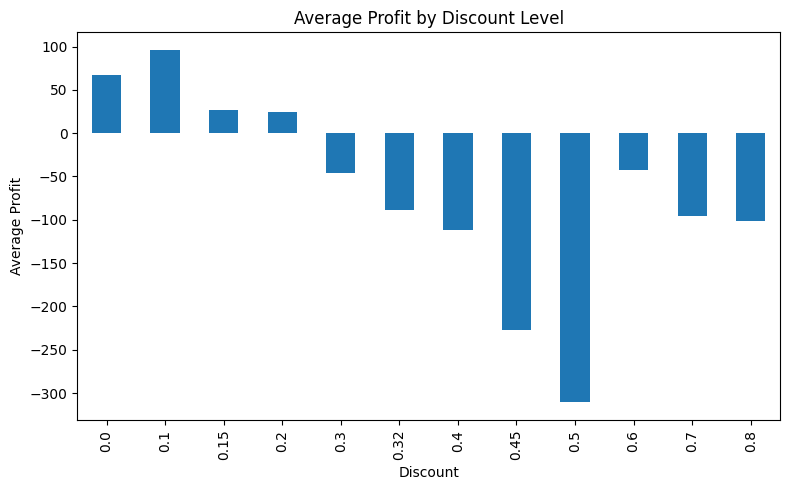

In [91]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.show()

# Discount vs Profit Analysis

## Key Findings

The highest average profit is achieved at the 10% discount level, suggesting that moderate discounting can stimulate demand while preserving healthy margins.

Profitability remains positive at lower discount levels but declines sharply as discounts increase.

Average profit becomes negative at discount levels above approximately 20%, indicating a clear threshold beyond which discounting begins to destroy value.

The 50% discount level generates the largest average loss among all discount categories.

## Business Insight

The analysis demonstrates that aggressive discounting is one of the primary drivers of profit erosion.

While small discounts can support revenue generation, excessive discount levels significantly reduce profitability and often result in loss-making transactions.

The findings strongly support the previously observed negative correlation between discount and profit.

## Recommendation

Management should establish tighter controls on discounts above 20%.

The current analysis suggests that moderate discount strategies may be effective, while deep discounting should be limited to exceptional circumstances.

Special attention should be given to transactions involving 50% discounts, as these appear to generate the greatest financial losses.

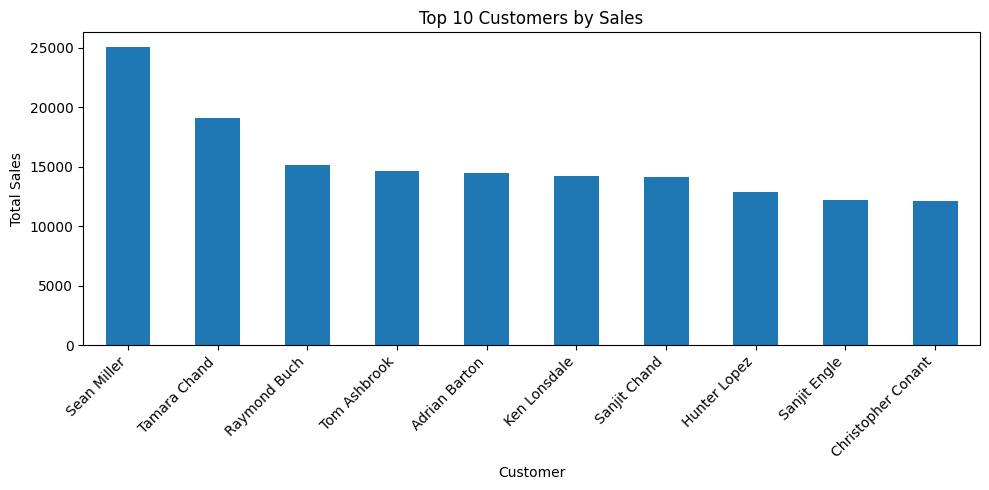

In [92]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Key Findings

A small group of customers contributes a disproportionately large share of total sales revenue. Sean Miller emerged as the highest-revenue customer, followed by Tamara Chand and Raymond Buch.

The sales distribution indicates that a limited number of customers account for a significant portion of overall business revenue, highlighting the presence of customer concentration.

## Business Insight

The business derives substantial revenue from a relatively small group of high-value customers. While these customers play a critical role in driving sales growth, excessive dependence on a few accounts increases revenue concentration risk.

Maintaining strong relationships with top customers is essential, as the loss of even a small number of key accounts could have a noticeable impact on overall sales performance.

## Recommendation

The company should implement targeted retention and loyalty initiatives for high-value customers while simultaneously expanding its customer base to reduce dependence on a limited number of accounts.

Regular monitoring of customer concentration metrics can help ensure sustainable and diversified revenue growth.

# Product Analysis

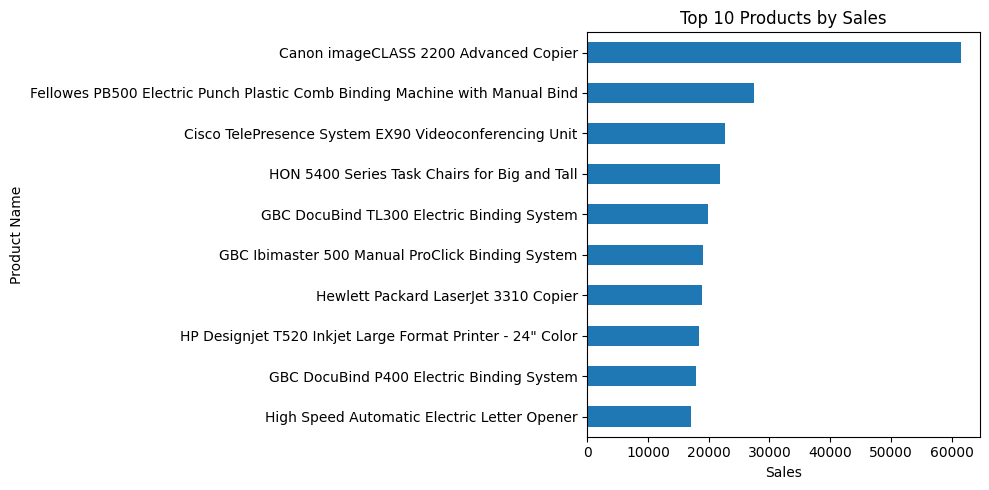

In [93]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")

plt.tight_layout()
plt.show()

## Key Findings

The Canon imageCLASS 2200 Advanced Copier emerged as the highest-selling product in the portfolio, generating significantly higher sales than most other products. The Top 10 products collectively account for a substantial share of total revenue, indicating that sales performance is concentrated among a relatively small group of products.

This concentration suggests that a limited number of products play a critical role in driving overall business performance.

## Business Insight

The strong performance of a few products highlights their importance as key revenue drivers for the business. While these products contribute significantly to sales growth, heavy dependence on a limited number of products may expose the company to demand fluctuations, competitive pressures, or supply chain disruptions.

Understanding which products consistently generate strong demand can help management make more effective inventory and product portfolio decisions.

## Recommendation

Management should prioritize inventory availability, marketing investments, and promotional efforts for top-performing products to maximize revenue opportunities. At the same time, the company should explore strategies to improve the performance of mid-tier products in order to diversify revenue sources and reduce product concentration risk.

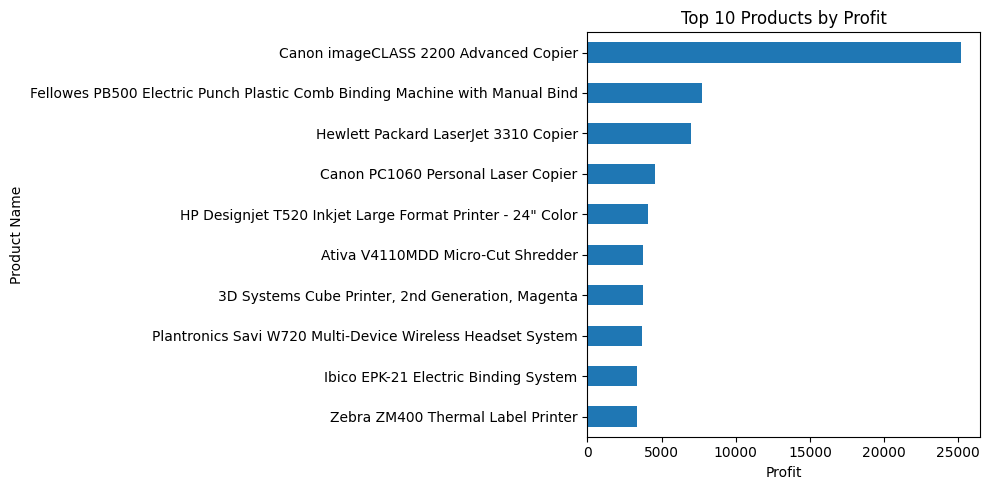

In [94]:
top_profit_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_profit_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

## Key Findings

The Canon imageCLASS 2200 Advanced Copier emerged as the most profitable product in the portfolio, generating significantly higher profit than other products. The Top 10 products contribute a substantial share of total company profit, indicating that profitability is concentrated among a relatively small number of high-performing products.

Several products generate strong profit contributions despite not necessarily being the highest-selling products, highlighting differences between revenue generation and value creation.

## Business Insight

Product profitability provides a more accurate measure of business value than sales alone. The concentration of profit among a limited group of products suggests that a small subset of the product portfolio plays a critical role in sustaining overall business performance.

Understanding which products consistently generate strong margins can help management allocate resources more effectively and improve portfolio-level profitability.

## Recommendation

Management should prioritize inventory planning, promotional efforts, and customer acquisition strategies around high-profit products. Regular monitoring of product-level profitability can help identify opportunities to strengthen margins and improve overall financial performance.

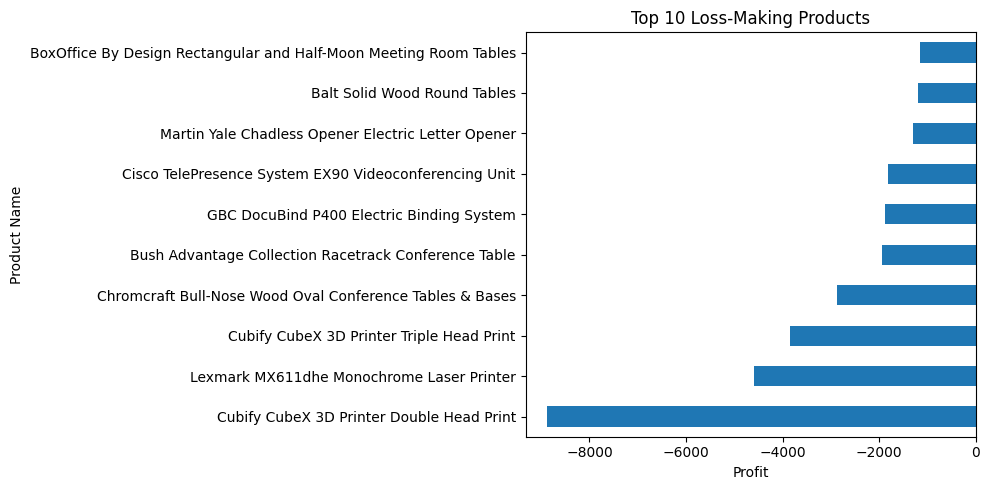

In [95]:
loss_products = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

plt.figure(figsize=(10,5))
loss_products.plot(kind="barh")

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

## Key Findings

Several products generated significant cumulative losses despite contributing sales revenue. The Cubify product line emerged among the largest loss-making products, indicating persistent profitability challenges within specific areas of the product portfolio.

These products contribute directly to margin erosion and reduce the overall profitability generated by higher-performing products.

## Business Insight

Revenue generation alone does not guarantee product success. Loss-making products may indicate issues related to excessive discounting, weak pricing strategies, high costs, or limited market demand.

Persistent underperformance within a small group of products can have a disproportionate impact on overall business profitability.

## Recommendation

Management should conduct a detailed review of pricing, discounting, and cost structures associated with loss-making products. Products with consistently negative profitability should be considered for strategic repositioning or portfolio rationalization.

# Shipping Analysis

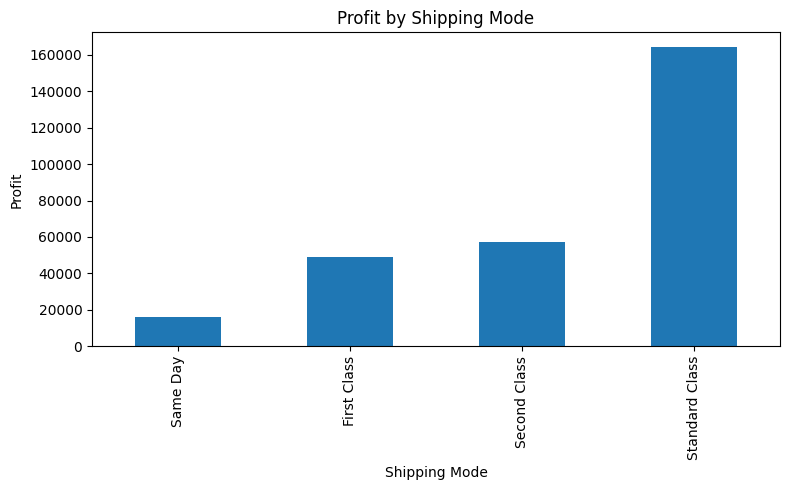

In [96]:
ship_profit = df.groupby("Ship Mode")["Profit"].sum().sort_values()

plt.figure(figsize=(8,5))

ship_profit.plot(kind="bar")

plt.title("Profit by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

## Key Findings

Profitability varies noticeably across shipping modes, with Standard Class generating the highest total profit among all delivery options. The higher profitability of Standard Class can be attributed to its large order volume and relatively lower fulfillment costs compared to expedited shipping methods.

Premium shipping modes contribute less to overall profit despite offering faster delivery services.

## Business Insight

The analysis suggests that faster shipping options do not necessarily translate into higher profitability. While premium delivery methods may enhance customer experience, they can also increase operational costs and place pressure on profit margins.

The strong performance of Standard Class highlights the importance of balancing service quality with cost efficiency.

## Recommendation

Management should continue leveraging Standard Class as the primary fulfillment method while carefully monitoring the profitability of premium shipping options. Regular evaluation of shipping costs and customer preferences can help optimize delivery strategies and improve overall margins.

# Customer Analysis

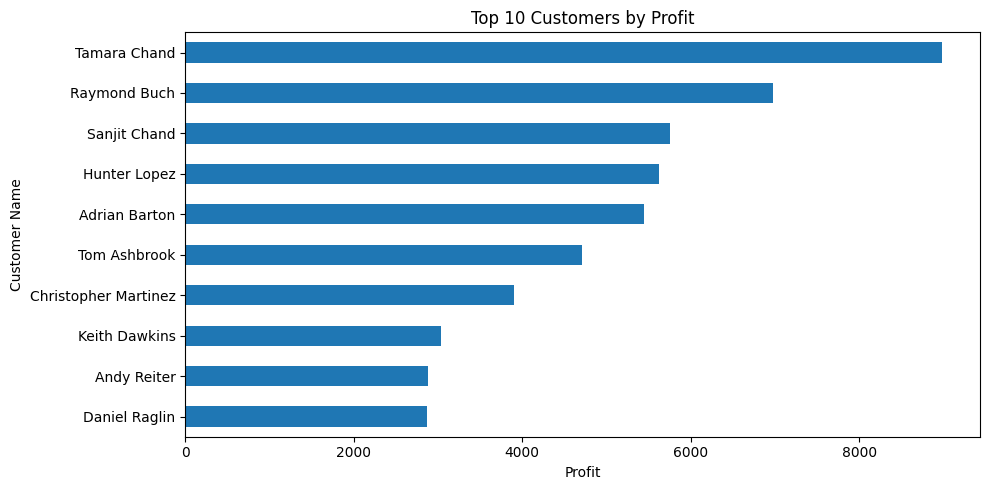

In [97]:
top_profit_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_profit_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

## Key Findings

Tamara Chand emerged as the most profitable customer, generating approximately $8.98K in profit, followed by Raymond Buch ($6.98K) and Sanjit Chand ($5.76K). The Top 10 customers collectively contribute a significant share of overall company profit, highlighting the concentration of profitability among a relatively small group of customers.

The noticeable gap between the highest and lower-ranked profitable customers indicates substantial variation in customer-level value creation across the customer base.

## Business Insight

Customer profitability is not evenly distributed. A relatively small number of customers generate a disproportionate share of total profit, making them strategically important to the business.

Focusing on profitable customer relationships can often create greater financial impact than pursuing revenue growth alone.

## Recommendation

Management should prioritize retention and relationship-building efforts for high-profit customers such as Tamara Chand, Raymond Buch, and Sanjit Chand. Incorporating profitability-based customer segmentation can help allocate resources more effectively and maximize long-term customer value.

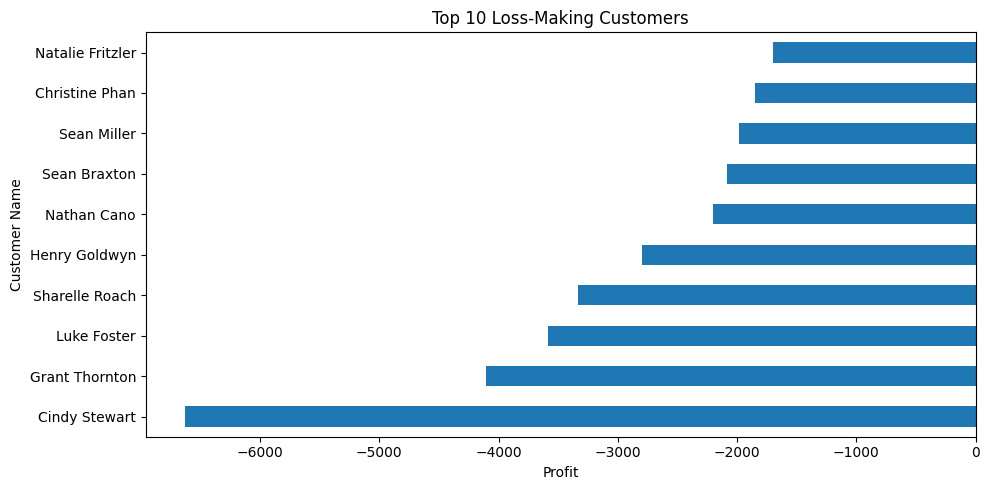

In [98]:
bottom_profit_customers = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,5))

bottom_profit_customers.plot(kind="barh")

plt.title("Top 10 Loss-Making Customers")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

## Key Findings

Cindy Stewart emerged as the largest loss-making customer, generating a cumulative loss of approximately $6.63K, followed by Grant Thornton (-$4.11K) and Luke Foster (-$3.58K). The Top 10 loss-making customers collectively account for a substantial amount of negative profit, indicating that a small group of customers contributes disproportionately to profitability leakage.

The analysis highlights significant variation in customer-level profitability, with some customers generating consistent losses despite contributing sales revenue.

## Business Insight

Revenue generation alone does not guarantee customer value. Excessive discounting, low-margin product purchases, or unfavorable purchasing patterns may be driving losses among certain customer accounts.

These findings reinforce the importance of evaluating customers based on profitability rather than sales volume alone.

## Recommendation

Management should review pricing strategies, discount practices, and purchasing behavior associated with loss-making customers such as Cindy Stewart, Grant Thornton, and Luke Foster. Targeted actions aimed at improving customer-level margins can help reduce profitability leakage and strengthen overall business performance.

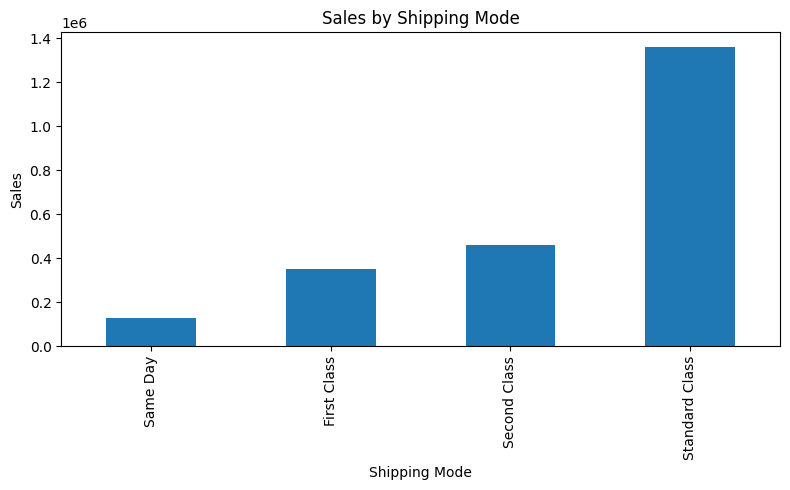

In [99]:
ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values()

plt.figure(figsize=(8,5))

ship_sales.plot(kind="bar")

plt.title("Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

## Key Findings

Standard Class generated the highest sales at approximately $1.36M, significantly outperforming all other shipping modes. Second Class and First Class contributed approximately $459K and $351K in sales respectively, while Same Day delivery generated the lowest sales at approximately $128K.

The substantial gap between Standard Class and the remaining shipping modes indicates a strong customer preference for standard delivery options.

## Business Insight

The dominance of Standard Class suggests that customers are generally willing to prioritize cost-effective delivery over faster shipping options. The concentration of sales within a single shipping mode also highlights its importance in supporting overall business revenue.

Understanding customer delivery preferences can help improve fulfillment planning and operational efficiency.

## Recommendation

Management should continue optimizing Standard Class operations to support growing demand while ensuring service reliability. At the same time, opportunities to increase adoption of premium shipping options should be explored where customer demand and profitability justify the additional service offering.

In [100]:
category_metrics = df.groupby("Category")[["Sales","Profit"]].sum()

category_metrics["Profit Margin %"] = (
    category_metrics["Profit"] / category_metrics["Sales"]
) * 100

print(category_metrics)

                       Sales       Profit  Profit Margin %
Category                                                  
Furniture        741999.7953   18451.2728         2.486695
Office Supplies  719047.0320  122490.8008        17.035158
Technology       836154.0330  145454.9481        17.395712


## Key Findings

Technology emerged as the strongest category, generating approximately $836K in sales and $145K in profit while achieving the highest profit margin of 17.40%. Office Supplies also delivered strong performance with over $719K in sales, $122K in profit, and a profit margin of 17.04%.

In contrast, Furniture generated substantial sales of approximately $742K but produced only $18K in profit, resulting in a significantly lower profit margin of 2.49%.

## Business Insight

The analysis highlights that high sales do not necessarily translate into high profitability. While Technology and Office Supplies convert revenue into profit efficiently, Furniture struggles to generate meaningful returns despite strong revenue performance.

These findings reinforce earlier observations regarding the weak profitability of Furniture and its loss-making sub-categories.

## Recommendation

Management should continue investing in high-performing categories such as Technology and Office Supplies while prioritizing initiatives aimed at improving Furniture profitability. A review of pricing, discounting, and product mix within Furniture may help strengthen margins and overall category performance.

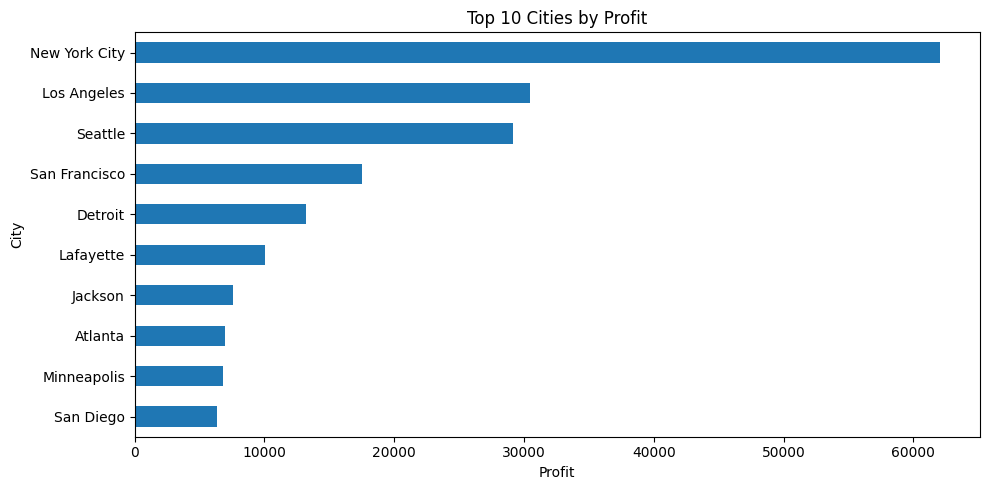

In [101]:
top_cities = (
    df.groupby("City")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_cities.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Profit")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

## Key Findings

New York City emerged as the most profitable city, generating approximately $62K in profit, followed by Los Angeles ($30K) and Seattle ($29K). The Top 10 cities collectively contribute a significant share of total company profit, highlighting the concentration of profitability within a relatively small number of geographic markets.

The substantial gap between New York City and the remaining cities indicates its critical role in driving overall business performance.

## Business Insight

Profitability is not evenly distributed across locations. High-performing cities such as New York City, Los Angeles, and Seattle serve as key profit centers, suggesting strong customer demand and favorable market conditions in these regions.

Understanding the characteristics of these successful markets can provide valuable insights for future expansion and growth initiatives.

## Recommendation

Management should continue strengthening its presence in high-performing cities while analyzing the factors driving their success. Best practices from these markets can be leveraged to improve profitability and performance in lower-performing locations.

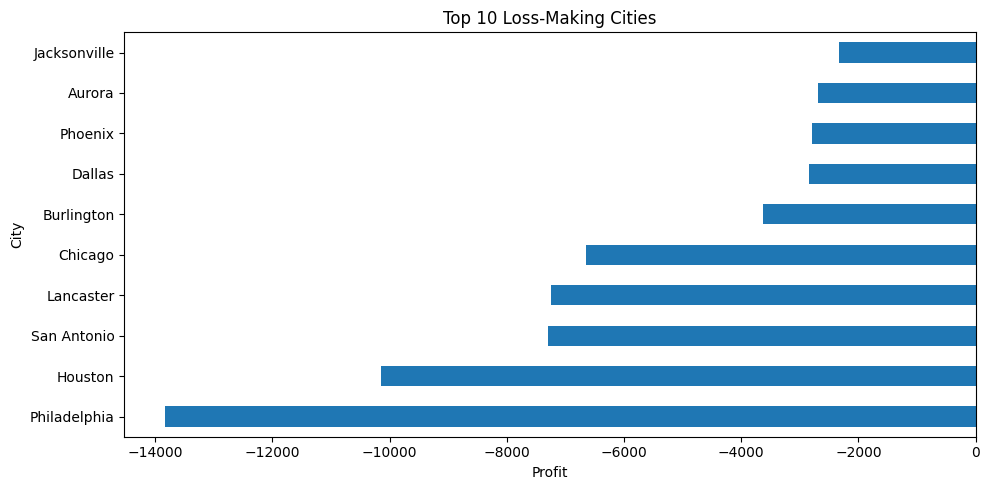

In [102]:
bottom_cities = (
    df.groupby("City")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,5))
bottom_cities.plot(kind="barh")

plt.title("Top 10 Loss-Making Cities")
plt.xlabel("Profit")

plt.tight_layout()
plt.show()

## Key Findings

Philadelphia emerged as the largest loss-making city, generating a cumulative loss of approximately $13.84K, followed by Houston (-$10.15K) and San Antonio (-$7.30K). The Top 10 loss-making cities collectively account for a substantial portion of the company’s geographic losses, highlighting significant profitability challenges in specific markets.

The magnitude of losses varies considerably across cities, indicating that geographic performance is not uniformly distributed across the business.

## Business Insight

Strong sales activity within a city does not necessarily translate into profitability. Factors such as aggressive discounting, unfavorable product mix, operational inefficiencies, or local market conditions may be contributing to persistent losses in cities such as Philadelphia, Houston, and San Antonio.

These findings emphasize the importance of evaluating market performance through both revenue and profitability metrics.

## Recommendation

Management should conduct detailed market-level reviews of loss-making cities to identify the root causes of underperformance. Targeted improvements in pricing, discount management, product strategy, and operational efficiency can help reduce losses and improve overall geographic profitability.

# Correlation Analysis

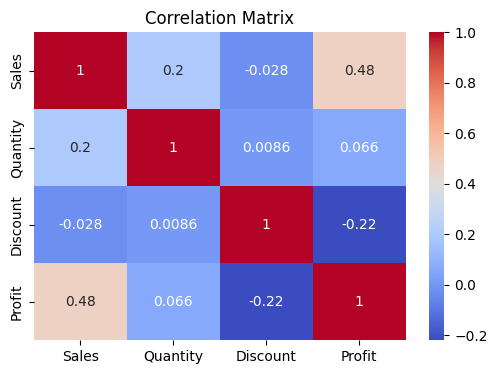

In [103]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    df[["Sales","Quantity","Discount","Profit"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Key Findings

The correlation matrix reveals a moderate positive relationship between Sales and Profit (0.48), indicating that higher sales generally contribute to higher profitability. In contrast, Discount exhibits a negative correlation with Profit (-0.22), suggesting that increased discounting tends to reduce profit levels.

Quantity shows only a weak relationship with both Sales and Profit, indicating that order volume alone is not a strong driver of business performance.

## Business Insight

The analysis suggests that profitability is influenced more by revenue generation and pricing decisions than by the number of units sold. While increasing sales can support profit growth, excessive discounting may erode margins and weaken overall financial performance.

These findings reinforce the importance of balancing revenue growth with effective pricing and margin management strategies.

## Recommendation

Management should focus on driving profitable sales growth while maintaining disciplined discounting practices. Regular monitoring of pricing strategies and profit margins can help maximize profitability without relying excessively on promotional discounts.

# Strategic Business Analysis

In [104]:
region_metrics = df.groupby("Region")[["Sales","Profit"]].sum()

region_metrics["Profit Margin %"] = (
    region_metrics["Profit"] / region_metrics["Sales"]
) * 100

print(region_metrics)

               Sales       Profit  Profit Margin %
Region                                            
Central  501239.8908   39706.3625         7.921629
East     678781.2400   91522.7800        13.483399
South    391721.9050   46749.4303        11.934342
West     725457.8245  108418.4489        14.944831


# Profit Margin by Region Analysis

## Key Findings

The West region achieved the highest profit margin at 14.94%, followed by the East region at 13.48%.

The South region generated a profit margin of 11.93%, while the Central region recorded the lowest margin at 7.92%.

The difference between the West and Central regions indicates substantial variation in operational efficiency and profitability across geographic markets.

## Business Insight

The West region not only generates the highest profit but also converts sales into profit more efficiently than any other region.

The Central region's significantly lower profit margin suggests that factors such as discounting practices, product mix, or regional market conditions may be reducing profitability.

## Recommendation

Management should investigate the operational and commercial strategies used in the West region and evaluate whether similar practices can be implemented in the Central region.

Further analysis should be conducted to identify the root causes of low profitability in Central markets.

In [107]:
df["Year"] = df["Order Date"].dt.year

yearly_sales = df.groupby("Year")["Sales"].sum()

print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


In [108]:
growth = yearly_sales.pct_change() * 100

print(growth)

Year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64


# Year-over-Year Sales Growth Analysis

## Key Findings

Total sales declined slightly by 2.83% in 2015 compared to 2014.

The business experienced a strong recovery in 2016, achieving sales growth of 29.47%.

Growth remained robust in 2017, with sales increasing by 20.36%.

Overall sales increased from approximately 484,000 in 2014 to more than 733,000 in 2017.

## Business Insight

Following a brief decline in 2015, the company successfully returned to a high-growth trajectory.

The strong growth observed in 2016 and 2017 suggests expanding market demand, improved business performance, and effective revenue generation strategies.

## Recommendation

Management should analyze the drivers behind the strong growth achieved during 2016 and 2017 and identify opportunities to sustain similar growth rates in future periods.

Continued investment in high-performing products, regions, and customer segments may help support long-term expansion.

In [109]:
total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

profit_margin = (total_profit / total_sales) * 100

avg_discount = df["Discount"].mean() * 100

total_orders = df["Order ID"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Profit Margin %:", profit_margin)
print("Average Discount %:", avg_discount)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Profit Margin %: 12.467217240315604
Average Discount %: 15.620272163297976
Total Orders: 5009


In [110]:
loss_orders = (df["Profit"] < 0).sum()

total_rows = len(df)

loss_percentage = (loss_orders / total_rows) * 100

print("Loss-Making Orders:", loss_orders)
print("Percentage of Loss-Making Orders:", loss_percentage)

Loss-Making Orders: 1871
Percentage of Loss-Making Orders: 18.721232739643785


# Loss-Making Orders Analysis

## Key Findings

A total of 1,871 transactions generated negative profit, representing approximately 18.72% of all transactions.

This indicates that nearly one out of every five orders resulted in a financial loss for the company.

## Business Insight

The relatively high proportion of loss-making transactions suggests that profitability challenges are not limited to a small number of exceptional cases.

Previous analyses identified excessive discounting, low-margin Furniture products, and loss-making sub-categories such as Tables and Bookcases as potential drivers of negative profitability.

The presence of a large number of loss-making transactions highlights the importance of monitoring transaction-level profitability rather than relying solely on overall sales growth.

## Recommendation

Management should establish profitability controls to identify and reduce loss-making transactions.

Particular attention should be given to discount-heavy orders, underperforming product categories, and regions with below-average profit margins.

In [111]:
pivot = pd.pivot_table(
    df,
    values="Profit",
    index="Category",
    columns="Segment",
    aggfunc="sum"
)

print(pivot)

Segment            Consumer   Corporate  Home Office
Category                                            
Furniture         6991.0786   7584.8158    3875.3784
Office Supplies  56330.3210  40227.3202   25933.1596
Technology       70797.8096  44166.9980   30490.1405


# Category and Segment Profitability Analysis

## Key Findings

Technology is the highest-profit category across all customer segments, followed by Office Supplies.

Furniture generates the lowest profit in every customer segment, including Consumer, Corporate, and Home Office.

No customer segment demonstrates strong Furniture profitability relative to other categories.

## Business Insight

The consistent underperformance of Furniture across all segments suggests that the category's profitability challenges are structural rather than segment-specific.

This indicates that factors such as pricing strategy, discount levels, product mix, or operational costs may be affecting profitability across the entire category.

Technology and Office Supplies remain the primary profit drivers regardless of customer segment.

## Recommendation

Management should conduct a category-wide review of Furniture operations rather than focusing on individual customer segments.

Improving pricing strategies, reducing excessive discounting, and optimizing the Furniture product portfolio may significantly improve overall profitability.

# Executive Summary

## Major Findings

### 1. Technology is the Primary Profit Driver

Technology contributed 50.79% of total company profit and achieved the highest profit margin (17.40%), making it the most valuable product category.

### 2. Furniture Generates Revenue but Limited Profit

Despite generating approximately 742,000 in sales, Furniture contributed only 6.44% of total profit and recorded a profit margin of just 2.49%.

### 3. Discounts Negatively Impact Profitability

Correlation analysis revealed a negative relationship between discounts and profit. Higher discount levels were frequently associated with lower profitability and several high-discount groups generated negative average profits.

### 4. Nearly One-Fifth of Transactions Are Loss-Making

A total of 1,871 transactions (18.72% of all orders) generated negative profit, highlighting the importance of transaction-level profitability monitoring.

### 5. West Region Outperforms All Other Markets

The West region generated the highest total profit and achieved the strongest profit margin (14.94%), while the Central region recorded the lowest margin (7.92%).

### 6. Business Growth Accelerated Significantly After 2015

Sales declined slightly in 2015 (-2.83%) but recovered strongly in 2016 (+29.47%) and continued growing in 2017 (+20.36%).

### 7. Revenue Is Well Diversified Across Customers

The top 10 customers contributed only 6.70% of total sales, indicating low customer concentration risk and a diversified revenue base.

### 8. High Sales Do Not Always Translate into High Profit

Customer analysis showed that top revenue-generating customers were not always the most profitable customers, emphasizing the need to evaluate customer value using profitability metrics.

### 9. Product Performance Is Highly Concentrated

The Canon imageCLASS 2200 Advanced Copier emerged as the highest-performing product in both sales and profit, while Cubify products contributed significantly to company losses.

### 10. Furniture Profitability Issues Are Category-Wide

Category-Segment analysis showed that Furniture generated the lowest profit across all customer segments, suggesting structural profitability challenges rather than segment-specific issues.

## Final Recommendation

The company should prioritize profitability improvement initiatives focused on Furniture products, discount optimization, and loss-making transactions. Simultaneously, management should continue investing in high-performing Technology products and leverage successful practices from the West region to improve overall business performance.

# Business Recommendations

### Recommendation 1: Optimize Discount Strategy

**Key Finding:** A strong negative correlation (-0.67) exists between Discount and Profit, with profitability declining significantly beyond the 20% discount level.

**Business Insight:** Excessive discounting is a major driver of profit erosion despite supporting sales growth.

**Recommendation:** Implement stricter discount controls and prioritize targeted promotions to balance revenue growth with profitability.

---

### Recommendation 2: Focus on High-Margin Categories

**Key Finding:** Technology generated the highest profit ($145.5K) and profit margin (17.4%), while Furniture recorded the lowest margin (2.5%).

**Business Insight:** Category performance varies significantly, with Technology acting as the primary profit driver.

**Recommendation:** Increase focus on Technology products while reviewing pricing and cost structures within the Furniture category.

---

### Recommendation 3: Improve Regional Performance

**Key Finding:** The West region delivered the highest profitability, while cities such as Philadelphia and Houston generated substantial losses.

**Business Insight:** Regional profitability differences indicate opportunities to replicate successful strategies and address underperforming markets.

**Recommendation:** Apply best practices from high-performing regions and investigate the root causes of losses in underperforming cities.

---

### Recommendation 4: Strengthen Customer & Product Portfolio Management

**Key Finding:** A small group of customers and products contributed a significant share of overall profits, while several customers and products consistently generated losses.

**Business Insight:** Profitability is concentrated among a limited set of high-value customers and products.

**Recommendation:** Retain high-profit customers, promote profitable products, and review pricing or discount strategies for loss-making segments.

---

### Recommendation 5: Enhance Operational Efficiency

**Key Finding:** Standard Class accounted for the majority of sales volume, making it the most preferred shipping mode.

**Business Insight:** Efficient shipping operations can improve customer satisfaction while controlling fulfillment costs.

**Recommendation:** Continue optimizing Standard Class operations and explore opportunities to improve delivery efficiency across all shipping modes.